In [4]:
# obtain the heat masks of an exit sequence
# data: /Users/entomophile/Desktop/FYP/entry_exit_detection/presence_detection_workspace/data/office0_4
import sys
sys.path.append('/Users/entomophile/Desktop/FYP/entry_exit_detection/presence_detection_workspace/src')
import yaml
import json   
from organizer_module.postprocessor import PostProcessor
from dataset.dataset import ThermalDataset
from heatsource_detection_module.extract import HeatSourceDetector
from posture_detection_module.CNN_model import SimpleIRA_CNN
from posture_detection_module.utils import remap_labels_simple, inverse_remap_labels_simple, label_to_text_simple, ThermalInvariantPreprocessor
from organizer_module.track_kalman import Tracker
from data_visualization_module.plot import DataVisualizer
import torch
import cv2
from tqdm import tqdm
import numpy as np


dataset office0_2; length: 15525


  0%|          | 0/10 [00:00<?, ?it/s]

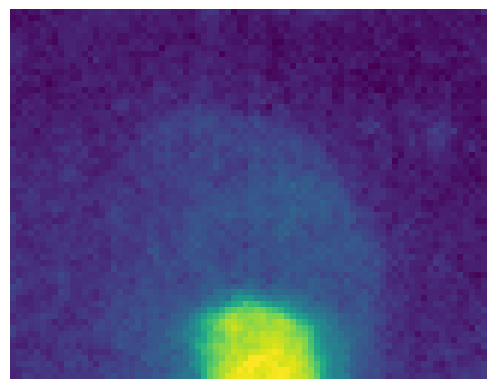

num of pixels detected as heat source:  251


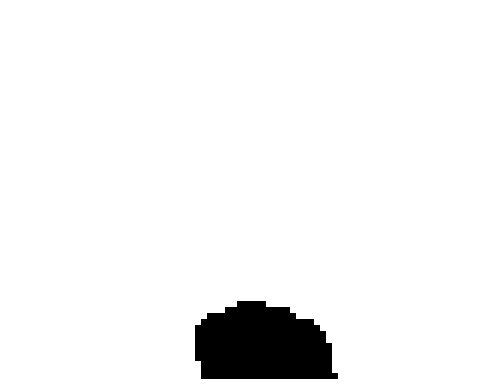

/Users/entomophile/mambaforge/envs/py3.10_temp/lib/python3.10/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/entomophile/mambaforge/envs/py3.10_temp/lib/python3.10/site-packages/numpy/core/_methods.py:127: RuntimeWarning: invalid value encountered in divide
  ret = arr.dtype.type(ret / rcount)
 10%|█         | 1/10 [00:00<00:01,  4.71it/s]

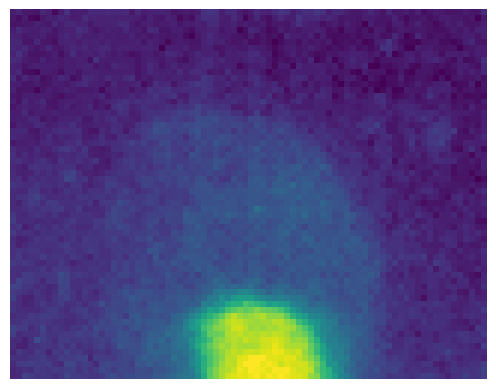

num of pixels detected as heat source:  250


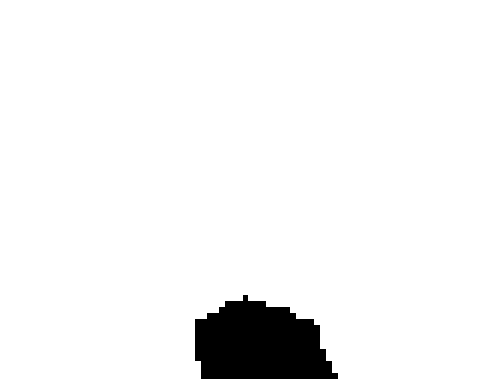

 20%|██        | 2/10 [00:00<00:01,  5.67it/s]

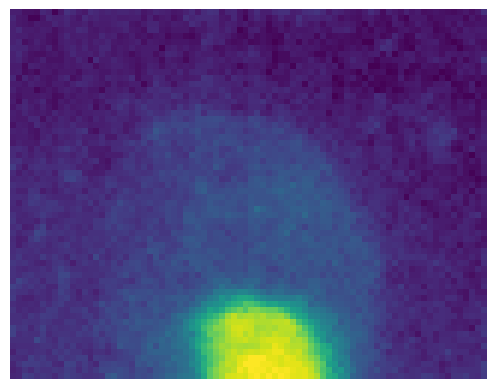

num of pixels detected as heat source:  260


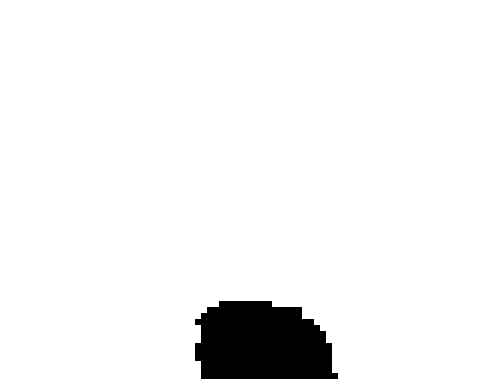

 30%|███       | 3/10 [00:00<00:01,  4.67it/s]

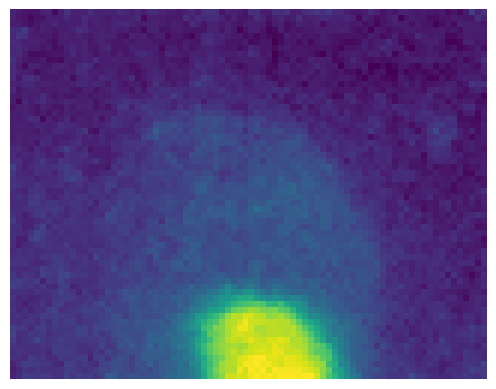

num of pixels detected as heat source:  268


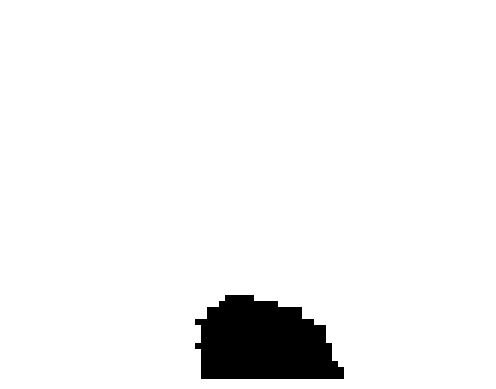

 40%|████      | 4/10 [00:00<00:01,  5.22it/s]

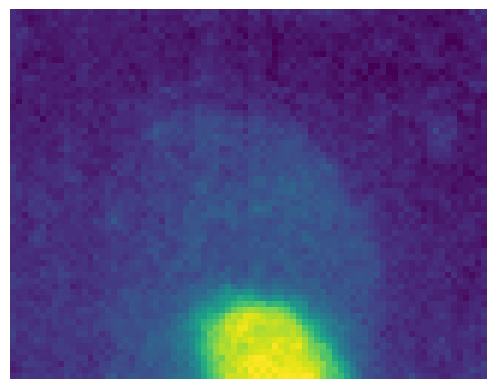

num of pixels detected as heat source:  271


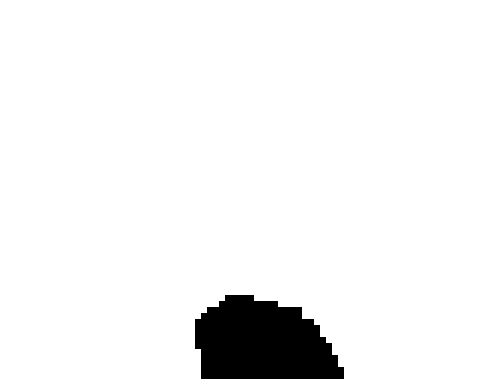

 50%|█████     | 5/10 [00:00<00:00,  6.27it/s]

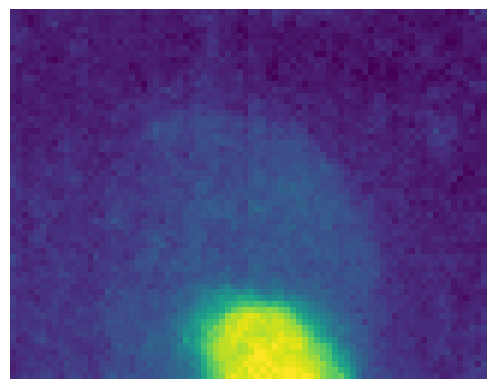

num of pixels detected as heat source:  280


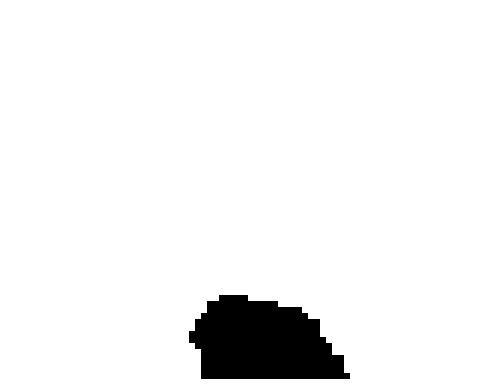

 60%|██████    | 6/10 [00:00<00:00,  7.10it/s]

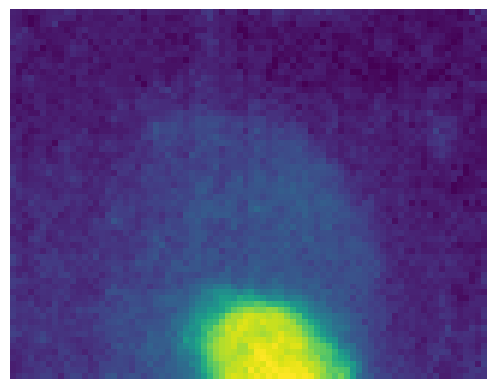

num of pixels detected as heat source:  284


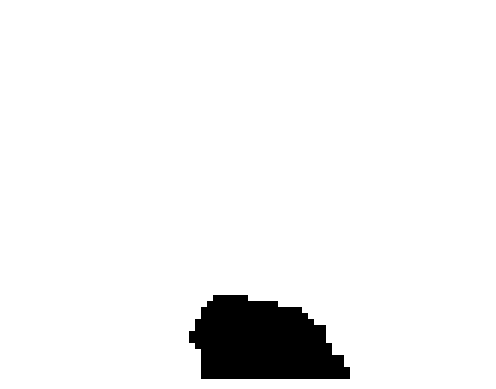

 70%|███████   | 7/10 [00:01<00:00,  5.46it/s]

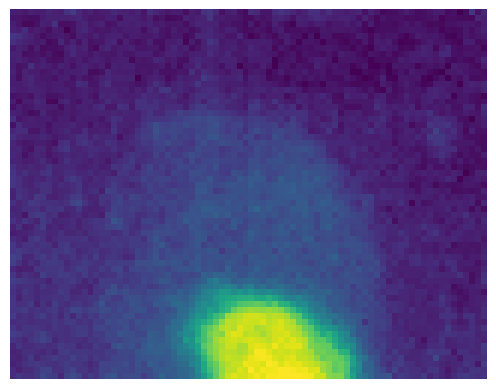

num of pixels detected as heat source:  305


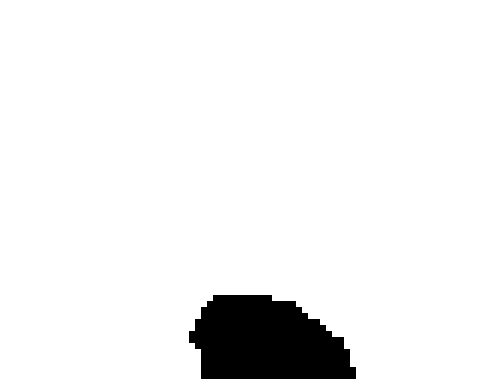

 80%|████████  | 8/10 [00:01<00:00,  5.22it/s]

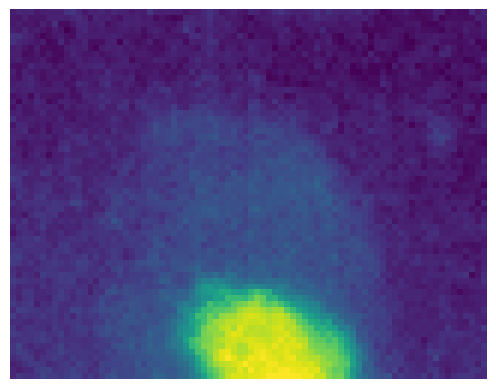

num of pixels detected as heat source:  332


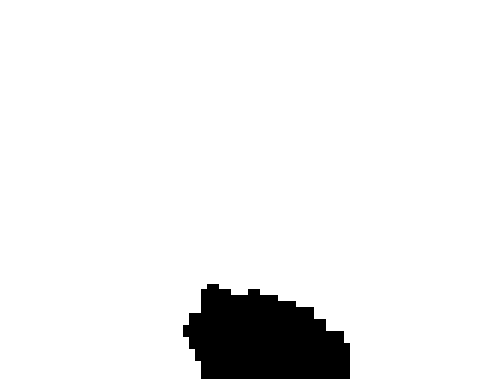

 90%|█████████ | 9/10 [00:01<00:00,  5.82it/s]

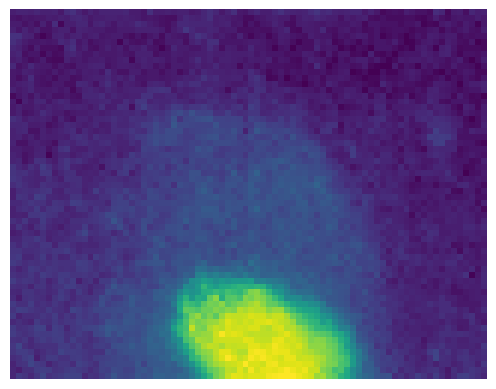

num of pixels detected as heat source:  368


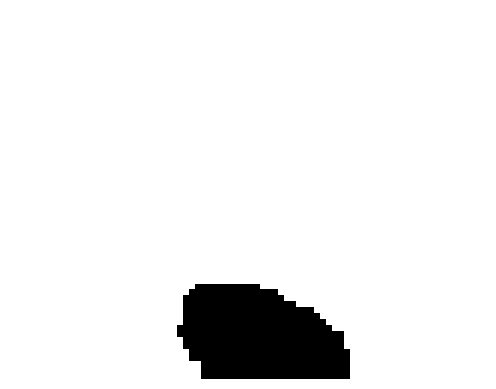

100%|██████████| 10/10 [00:02<00:00,  4.92it/s]


In [5]:
data_name = "office0_2"
# 1. load the dataset ===============================================
# dataset = ThermalDataset("/Users/entomophile/Desktop/FYP/entry_exit_detection/presence_detection_workspace/data/office1_0")
dataset = ThermalDataset(f"/Users/entomophile/Desktop/FYP/entry_exit_detection/presence_detection_workspace/data/{data_name}", noCam = True)
print(f"dataset {data_name}; length:", len(dataset))


# 2. initialize our system's components ==================================
#   2.1. heatsource detection module: load the module
heat_detector = HeatSourceDetector()
thermalinvariantpreprocessor = ThermalInvariantPreprocessor()
#   2.1. posture detector module: load the model
posture_detector_model = SimpleIRA_CNN()
# load the pretrained weights for posture detection model
posture_detector_model.load_state_dict(torch.load('/Users/entomophile/Desktop/FYP/entry_exit_detection/presence_detection_workspace/weights/all_current_data.pth'))
#   2.2. kalman tracker module: load the module
tracker = Tracker()
#   2.4. postprocessor module: load the module
postprocessor = PostProcessor()

import matplotlib.pyplot as plt
from tqdm import tqdm


# 3. loop through each fraome ========================================
#   3.1. prepare the ground truth label list
gt_result_lst = []
waittime = 1
visualization = True
start = 8535
start = 2045
end = start + 10
for idx in tqdm(range(start, end, 1)):
    # gt
    label = dataset.annotations_expanded[idx]
    gt_result_lst.append(label)

    # data
    ira_highres = dataset.get_ira_highres(idx)
    # make pixels less than 17 deg be 17 deg
    ira_highres[ira_highres < 18] = 18
    # flip ira_highres vertically to match the real orientation of the scene
    ira_highres = np.flipud(ira_highres)

    plt.imshow(ira_highres)
    # turn off axis    
    plt.axis('off')
    plt.show()

    #   3.1. detect heat source
    thresh, mask = heat_detector.get_thresh_mask_otsu(ira_highres)

    
    # print num of nonzero pixels in mask
    print("num of pixels detected as heat source: ", np.count_nonzero(mask))
    # flip mask bits
    mask = 1 - mask
    mask = (mask*255).astype(np.uint8)
    plt.imshow(mask, cmap='gray')
    plt.axis('off')
    plt.show()
    

    mask_individual = heat_detector.process_frame_connected_components(ira_highres, min_size=100)

    #   3.2. detect presence with kalman tracker
    tracker.update_blobs(mask_individual, ira_highres, heat_detector.get_unmasked_mean(ira_highres, mask), idx)
    postprocessor.get_blobs(tracker.blobs, idx)

    #   3.3. posture detection if kalman shows presence; record it in postprocessor
    hasHuman = False
    for blob in tracker.blobs:
        if blob.is_residual == False: # if it is classified as human
            hasHuman = True

    if hasHuman:
        # clip and normalize the ira_highres image, and convert to tensor before feeding into the posture detection model
        ira_highres = thermalinvariantpreprocessor(ira_highres)
        posture = posture_detector_model(torch.tensor(ira_highres, dtype=torch.float32).unsqueeze(0)) # add batch and channel dimension
        posture_label = torch.argmax(posture, dim=1).item()
        # print("DEBUG: posture label: ", posture_label)
        posture_label = inverse_remap_labels_simple(posture_label)  # remap the posture label
        # print("DEBUG: inverse remap posture label: ", posture_label)
        postprocessor.get_posture(posture_label, idx)  # inverse remap the posture label
        posture_str = label_to_text_simple(posture_label)
    else:
        posture_label = 0
        posture_str = label_to_text_simple(posture_label)
        postprocessor.get_posture(0, idx)



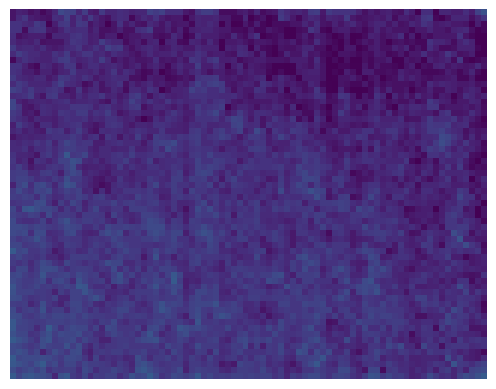

num of pixels detected as heat source:  698


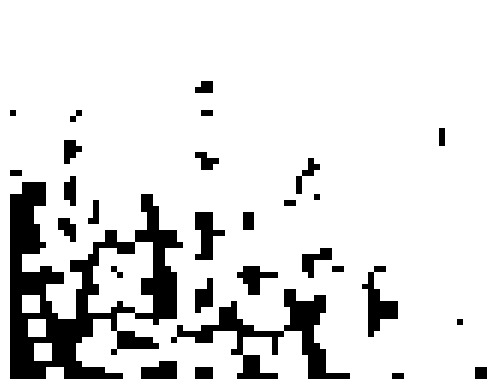

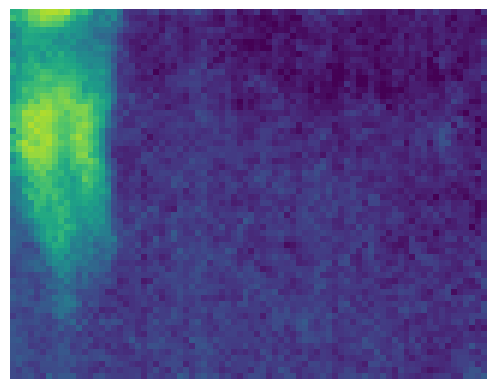

num of pixels detected as heat source:  587


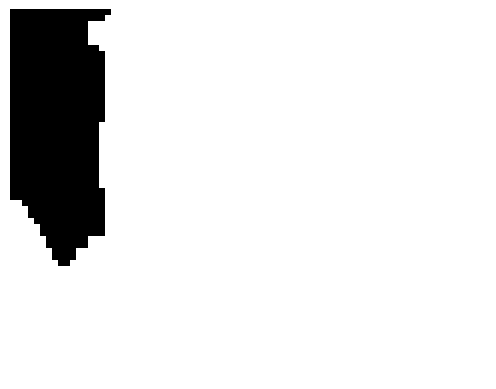

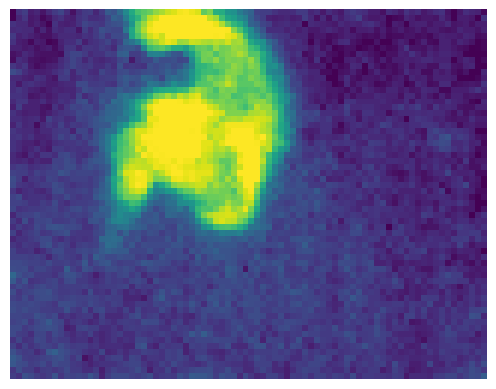

num of pixels detected as heat source:  624


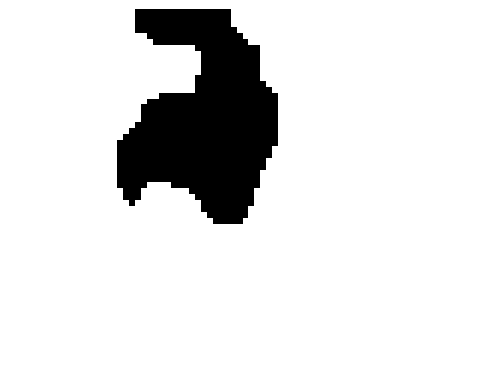

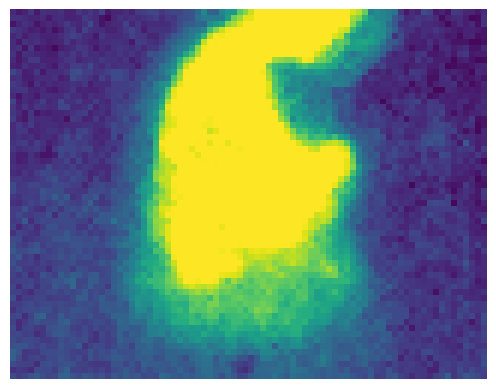

num of pixels detected as heat source:  1222


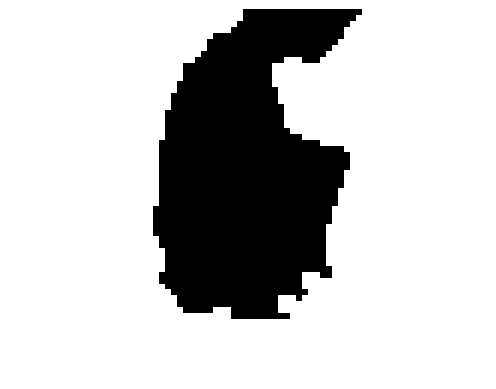

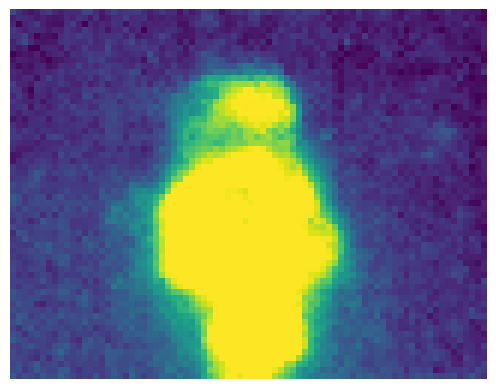

num of pixels detected as heat source:  990


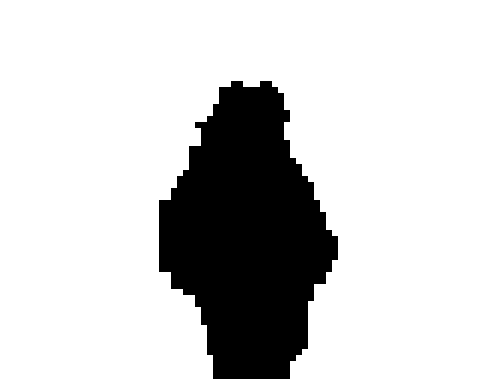

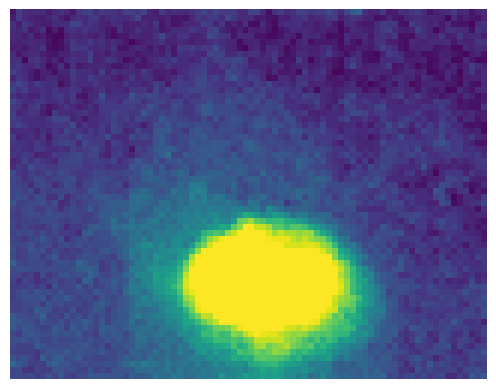

num of pixels detected as heat source:  454


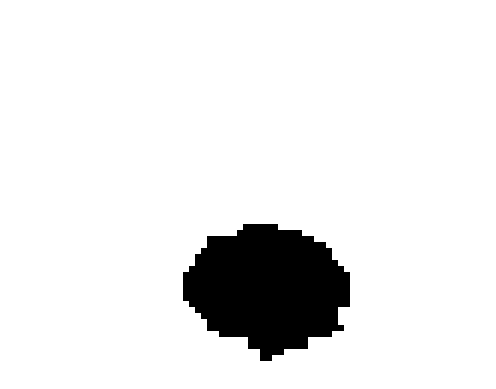

In [10]:
for idx in [240, 400, 600, 2800, 1400, 1700]:
    # gt
    label = dataset.annotations_expanded[idx]
    gt_result_lst.append(label)

    # data
    ira_highres = dataset.get_ira_highres(idx)
    # make pixels less than 17 deg be 17 deg
    ira_highres[ira_highres < 18] = 18
    # flip ira_highres vertically to match the real orientation of the scene
    ira_highres = np.flipud(ira_highres)

    plt.imshow(ira_highres, vmin = 19, vmax = 27) 

    # turn off axis    
    plt.axis('off')
    plt.show()

    #   3.1. detect heat source
    thresh, mask = heat_detector.get_thresh_mask_otsu(ira_highres)

    
    # print num of nonzero pixels in mask
    print("num of pixels detected as heat source: ", np.count_nonzero(mask))
    # flip mask bits
    mask = 1 - mask
    mask = (mask*255).astype(np.uint8)
    plt.imshow(mask, cmap='gray')
    plt.axis('off')
    plt.show()
    

    mask_individual = heat_detector.process_frame_connected_components(ira_highres, min_size=100)

    #   3.2. detect presence with kalman tracker
    tracker.update_blobs(mask_individual, ira_highres, heat_detector.get_unmasked_mean(ira_highres, mask), idx)
    postprocessor.get_blobs(tracker.blobs, idx)

    #   3.3. posture detection if kalman shows presence; record it in postprocessor
    hasHuman = False
    for blob in tracker.blobs:
        if blob.is_residual == False: # if it is classified as human
            hasHuman = True

    if hasHuman:
        # clip and normalize the ira_highres image, and convert to tensor before feeding into the posture detection model
        ira_highres = thermalinvariantpreprocessor(ira_highres)
        posture = posture_detector_model(torch.tensor(ira_highres, dtype=torch.float32).unsqueeze(0)) # add batch and channel dimension
        posture_label = torch.argmax(posture, dim=1).item()
        # print("DEBUG: posture label: ", posture_label)
        posture_label = inverse_remap_labels_simple(posture_label)  # remap the posture label
        # print("DEBUG: inverse remap posture label: ", posture_label)
        postprocessor.get_posture(posture_label, idx)  # inverse remap the posture label
        posture_str = label_to_text_simple(posture_label)
    else:
        posture_label = 0
        posture_str = label_to_text_simple(posture_label)
        postprocessor.get_posture(0, idx)



In [7]:
# load the dataset
data_path = '/Users/entomophile/Desktop/FYP/entry_exit_detection/presence_detection_workspace/data/office0_4'
dataset = Dataset(data_path)    

NameError: name 'Dataset' is not defined